<a href="https://colab.research.google.com/github/ved-ingole/TASK-2---Data-set-Preparation-and-data-analysis/blob/main/TASK_2_Dataset_Preparation_for_Diabetes_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


STEP 1 — LOADING DATASET

Dataset Loaded Successfully

Dataset Shape : (768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age target  
0                     0.627   50      1  
1                     0.351   31      0  
2                     0.672   32      1  
3                     0.167   21      0  
4                     2.288   33      1  

STEP 2 — DATASET PREPARATION

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                   

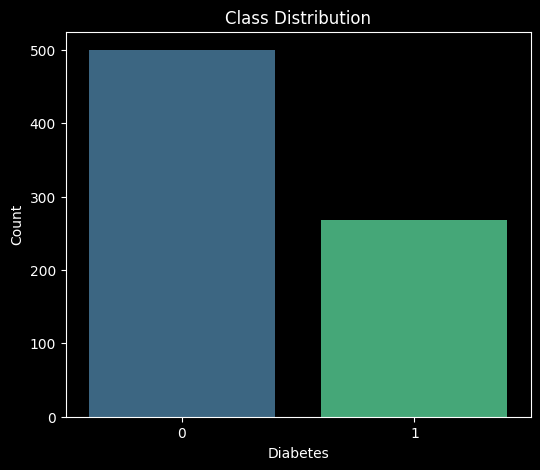

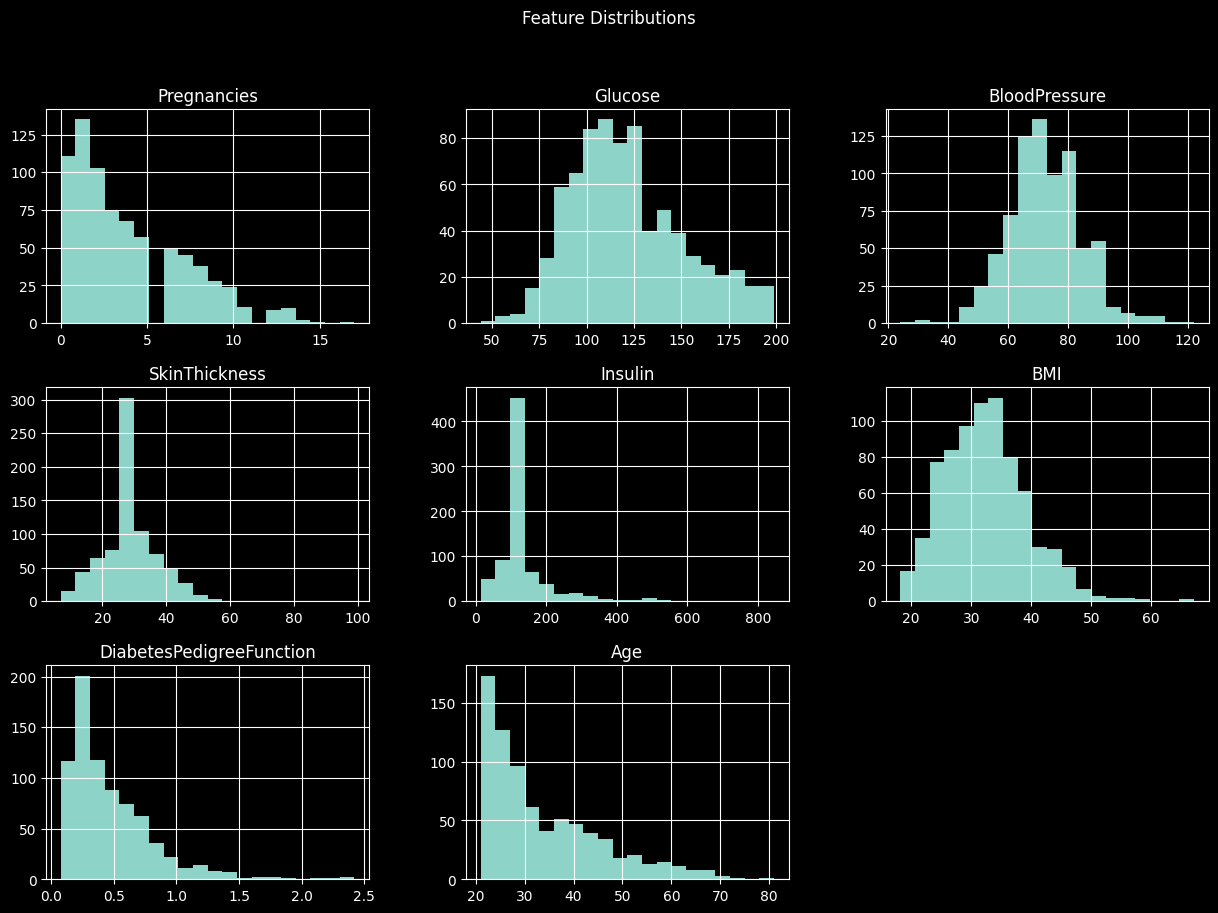

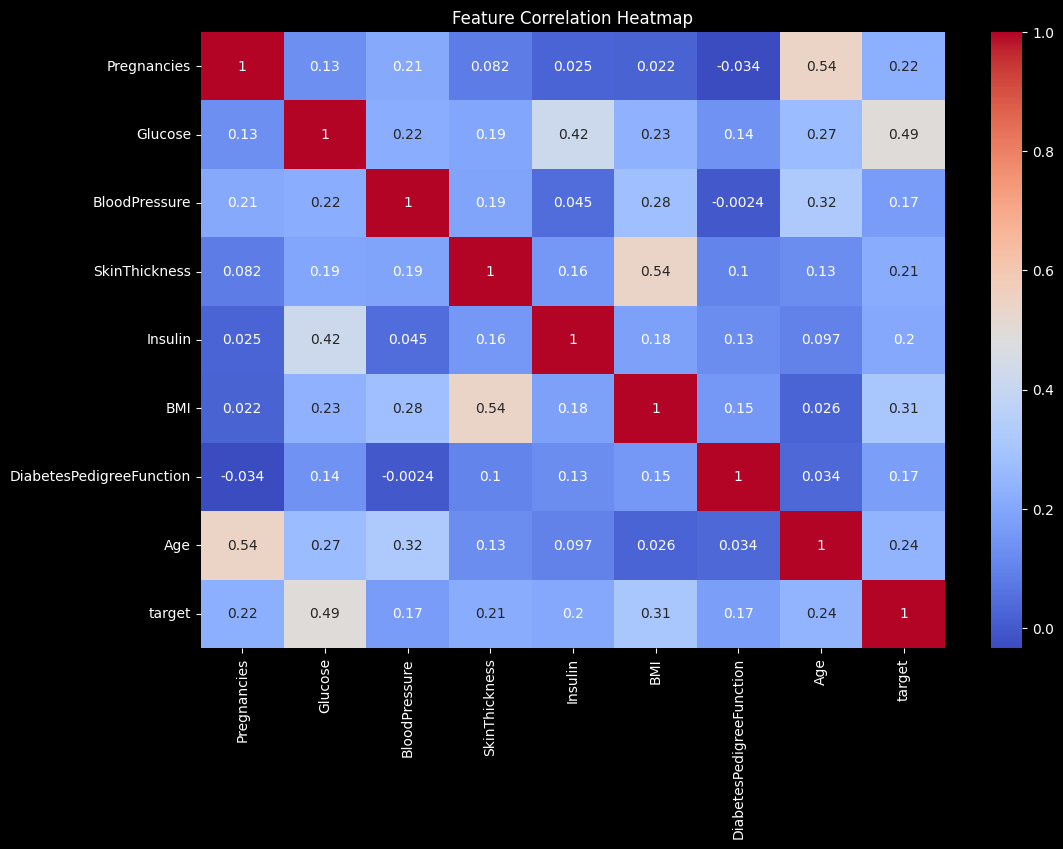


STEP 6 — IMPORTANT & IRRELEVANT FEATURES

Correlation With Target:
target                      1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: target, dtype: float64

Important Features:
target           1.000000
Glucose          0.492782
BMI              0.312038
Age              0.238356
Pregnancies      0.221898
SkinThickness    0.214873
Insulin          0.203790
Name: target, dtype: float64

Less Important Features:
Series([], Name: target, dtype: float64)

DATASET PREPARATION & FEATURE ANALYSIS COMPLETED


In [ ]:
# =============================================================
# IMPORT LIBRARIES
# =============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

# =============================================================
# STYLE SETTINGS
# =============================================================

plt.style.use("dark_background")

# =============================================================
# LOAD DATASET
# =============================================================

print("\n" + "="*60)
print("STEP 1 — LOADING DATASET")
print("="*60)

# dataset OpenML

diabetes = fetch_openml(
    name="diabetes",
    version=1,
    as_frame=True
) # Load PIMA Diabetes Dataset

df = diabetes.frame.copy()

# Rename target column
df.rename(columns={"class": "target"}, inplace=True)

# Convert target labels into numbers
df["target"] = df["target"].map({
    "tested_negative": 0,
    "tested_positive": 1
})

# Rename columns for readability
df.columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "target"
]

print("\nDataset Loaded Successfully")

print(f"\nDataset Shape : {df.shape}")

print("\nFirst 5 Rows:")
print(df.head())

# =============================================================
# DATASET PREPARATION
# =============================================================

print("\n" + "="*60)
print("STEP 2 — DATASET PREPARATION")
print("="*60)

print("\nMissing Values:")
print(df.isnull().sum())

# Replace impossible zero values with median

zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_columns:

    df[col] = df[col].replace(0, np.nan)
#Some medical columns cannot realistically be 0 like BMI, Glucose
    median_value = df[col].median()

#Median is more stable than mean when outliers exist.

    df[col].fillna(median_value, inplace=True)

print("\nZero values replaced with median")

print("\nUpdated Missing Values:")
print(df.isnull().sum())

# =============================================================
# BASIC FEATURE ANALYSIS
# =============================================================

print("\n" + "="*60)
print("STEP 3 — FEATURE ANALYSIS")
print("="*60)

print("\nStatistical Summary:")
print(df.describe())

# Variance calculation

feature_variance = df.select_dtypes(include=np.number).var().sort_values(ascending=False)

print("\nFeature Variance:")
print(feature_variance)

print("\nHigh variance features are generally more useful.")

# =============================================================
# CORRELATION ANALYSIS
# =============================================================

print("\n" + "="*60)
print("STEP 4 — CORRELATION ANALYSIS")
print("="*60)

corr_matrix = df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# Detect highly correlated features

print("\nHighly Correlated Features:")

threshold = 0.8

for i in range(len(corr_matrix.columns)):

    for j in range(i):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold: #Detect highly correlated features.

            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]

            print(f"{col1} ↔ {col2} = {corr_value:.2f}")

# =============================================================
# CLASS IMBALANCE ANALYSIS
# =============================================================

print("\n" + "="*60)
print("STEP 5 — CLASS IMBALANCE ANALYSIS")
print("="*60)

class_counts = df["target"].value_counts() #checks both classes are balanced

print("\nClass Distribution:")
print(class_counts)

negative_percent = (
    class_counts[0] / len(df)
) * 100

positive_percent = (
    class_counts[1] / len(df)
) * 100

print(f"\nNegative Cases : {negative_percent:.2f}%")
print(f"Positive Cases : {positive_percent:.2f}%")

print("\nDataset is slightly imbalanced.")

# =============================================================
# VISUALIZATION 1 — CLASS DISTRIBUTION
# =============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="target",
    data=df,
    palette="viridis"
) #diabetes vs non-diabetes count

plt.title("Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")

plt.show()

# =============================================================
# VISUALIZATION 2 — FEATURE DISTRIBUTION
# =============================================================

df.hist(
    figsize=(15,10),
    bins=20
) #show distributon of each feature

plt.suptitle("Feature Distributions")

plt.show()

# =============================================================
# VISUALIZATION 3 — CORRELATION HEATMAP
# =============================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# RED - Strong positive relation
# BLUE - Negative Relation

# =============================================================
# IMPORTANT & IRRELEVANT FEATURES
# =============================================================

print("\n" + "="*60)
print("STEP 6 — IMPORTANT & IRRELEVANT FEATURES")
print("="*60)

target_corr = corr_matrix["target"].sort_values(
    ascending=False
) #finds whcih feature affect diabetes most

print("\nCorrelation With Target:")
print(target_corr)

print("\nImportant Features:")
print(target_corr[abs(target_corr) > 0.2])

print("\nLess Important Features:")
print(target_corr[abs(target_corr) < 0.1])

# =============================================================
# PROJECT COMPLETED
# =============================================================

print("\n" + "="*60)
print("DATASET PREPARATION & FEATURE ANALYSIS COMPLETED")
print("="*60)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    float64 
 2   BloodPressure             768 non-null    float64 
 3   SkinThickness             768 non-null    float64 
 4   Insulin                   768 non-null    float64 
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   target                    768 non-null    category
dtypes: category(1), float64(6), int64(2)
memory usage: 49.0 KB
